<a href="https://colab.research.google.com/github/AI-fanatic24/machine-learning-foundations/blob/main/Heart_Disease_Prediction_Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

RANDOM_STATE = 55

In [ ]:
df = pd.read_csv('/content/heart.csv')

In [ ]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [ ]:
cat_variables = ['Sex','ChestPainType','RestingECG','ExerciseAngina','ST_Slope']

In [ ]:
df = pd.get_dummies(data = df, prefix=cat_variables, columns=cat_variables)

In [ ]:
df.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,0,1,0,...,0,0,0,1,0,1,0,0,0,1
1,49,160,180,0,156,1.0,1,1,0,0,...,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0.0,0,0,1,0,...,0,0,0,0,1,1,0,0,0,1
3,48,138,214,0,108,1.5,1,1,0,1,...,0,0,0,1,0,0,1,0,1,0
4,54,150,195,0,122,0.0,0,0,1,0,...,1,0,0,1,0,1,0,0,0,1


In [ ]:
features = [x for x in df.columns if x not in 'HeartDisease']
features

['Age',
 'RestingBP',
 'Cholesterol',
 'FastingBS',
 'MaxHR',
 'Oldpeak',
 'Sex_F',
 'Sex_M',
 'ChestPainType_ASY',
 'ChestPainType_ATA',
 'ChestPainType_NAP',
 'ChestPainType_TA',
 'RestingECG_LVH',
 'RestingECG_Normal',
 'RestingECG_ST',
 'ExerciseAngina_N',
 'ExerciseAngina_Y',
 'ST_Slope_Down',
 'ST_Slope_Flat',
 'ST_Slope_Up']

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(df[features], df['HeartDisease'], train_size=0.8, random_state = RANDOM_STATE)

In [ ]:
print("Traning Samples:", len(X_train))
print("Validation Samples:",len(X_val))

Traning Samples: 734
Validation Samples: 184


In [ ]:
min_samples_split_list = [2,10,30,50,100,200,300,500]
max_depth_list = [1,2,3,4,8,16,32,64,None]

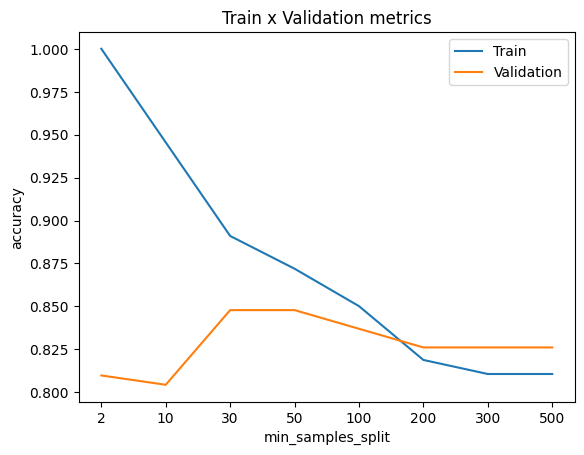

In [ ]:
accuracy_list_train = []
accuracy_list_val = []
for min_samples_split in min_samples_split_list:
  model = DecisionTreeClassifier(min_samples_split = min_samples_split, random_state = RANDOM_STATE).fit(X_train,y_train)

  predictions_train = model.predict(X_train)
  predictions_val = model.predict(X_val)
  accuracy_train = accuracy_score(predictions_train,y_train)
  accuracy_val = accuracy_score(predictions_val,y_val)
  accuracy_list_train.append(accuracy_train)
  accuracy_list_val.append(accuracy_val)

plt.title('Train x Validation metrics')
plt.xlabel('min_samples_split')
plt.ylabel('accuracy')
plt.xticks(ticks = range(len(min_samples_split_list)),labels=min_samples_split_list)
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_val)
plt.legend(['Train','Validation'])

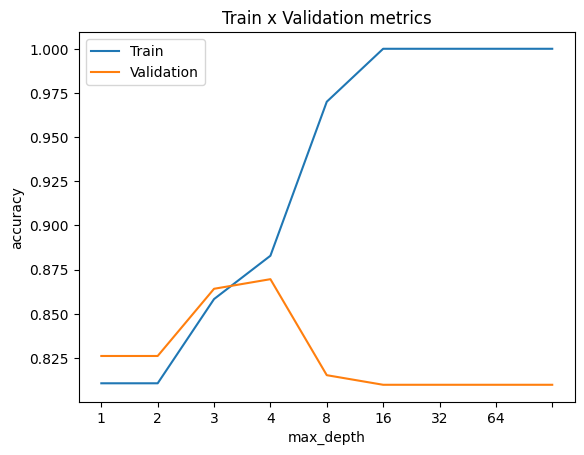

In [ ]:
accuracy_list_train = []
accuracy_list_val = []
for max_depth in max_depth_list:
  model = DecisionTreeClassifier(max_depth = max_depth, random_state = RANDOM_STATE).fit(X_train,y_train)

  predictions_train = model.predict(X_train)
  predictions_val = model.predict(X_val)
  accuracy_train = accuracy_score(predictions_train,y_train)
  accuracy_val = accuracy_score(predictions_val,y_val)
  accuracy_list_train.append(accuracy_train)
  accuracy_list_val.append(accuracy_val)

plt.title('Train x Validation metrics')
plt.xlabel('max_depth')
plt.ylabel('accuracy')
plt.xticks(ticks = range(len(max_depth_list)),labels=max_depth_list)
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_val)
plt.legend(['Train','Validation'])

Choosing:
max_depth = 4,
min_samples_split = 50

In [ ]:
decision_tree_model = DecisionTreeClassifier(min_samples_split=50,max_depth=4,random_state=RANDOM_STATE).fit(X_train,y_train)

In [ ]:
print("Training Metrics:")
print(accuracy_score(decision_tree_model.predict(X_train),y_train))
print('\n')
print("Validation metrics:")
print(accuracy_score(decision_tree_model.predict(X_val),y_val))

Training Metrics:
0.8664850136239782


Validation metrics:
0.8695652173913043
